<a href="https://colab.research.google.com/github/antas06/DL_Scratch/blob/Root_functions/Gradient_descent_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import time

In [3]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [4]:
df = pd.read_csv("/content/heart_data_.csv")

In [5]:
df.head()

,Age,Cholesterol,Heart_Disease,Blood_Pressure
0,63,284,1,125
1,53,294,1,125
2,39,277,0,115
3,67,182,0,132
4,32,264,0,116


In [6]:
df.shape

(300, 4)

In [7]:
target = "Heart_Disease"
X = df.drop(columns =[target])
y=df[target]

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
X_scaled.shape

(300, 3)

In [17]:
model1 = Sequential()

model1.add(Dense(10,activation="relu",input_dim = 3))
model1.add(Dense(10,activation="relu"))
model1.add(Dense(1,activation="sigmoid"))

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
#stochastic GD

model1.compile(loss="binary_crossentropy",metrics=["accuracy"])
start = time.time()
model1_data= model1.fit(X_scaled,y,epochs=100,batch_size = 1, validation_split=0.2)
print(time.time()-start)

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3976 - loss: 0.7640 - val_accuracy: 0.6667 - val_loss: 0.6303
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7093 - loss: 0.6081 - val_accuracy: 0.6667 - val_loss: 0.5928
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7741 - loss: 0.5188 - val_accuracy: 0.6667 - val_loss: 0.5819
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7080 - loss: 0.5484 - val_accuracy: 0.6667 - val_loss: 0.5850
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7465 - loss: 0.5345 - val_accuracy: 0.6667 - val_loss: 0.5792
Epoch 6/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7305 - loss: 0.5263 - val_accuracy: 0.6667 - val_loss: 0.5779
Epoch 7/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7403 - loss: 0.5170 - val_accuracy: 0.6833 - val_loss: 0.5765
Epoch 8/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7619 - loss: 0.4900 - val_accu

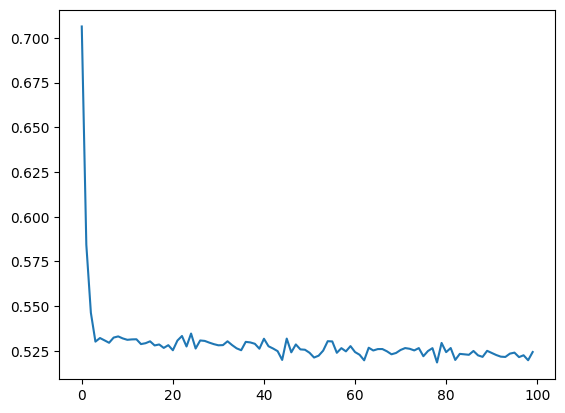

In [19]:
import matplotlib.pyplot as plt
plt.plot(model1_data.history['loss'])

In [27]:
model2= Sequential()

model2.add(Dense(10,activation="relu",input_dim = 3))
model2.add(Dense(10,activation="relu"))
model2.add(Dense(1,activation="sigmoid"))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model2.compile(loss="binary_crossentropy",metrics=["accuracy"])

In [29]:
#Batch GD

start = time.time()
model2_data= model2.fit(X_scaled,y,epochs=100,batch_size = 300, validation_split=0.2)
print(time.time()-start)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 608ms/step - accuracy: 0.6583 - loss: 0.6347 - val_accuracy: 0.7000 - val_loss: 0.6468
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6542 - loss: 0.6291 - val_accuracy: 0.7000 - val_loss: 0.6449
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6667 - loss: 0.6253 - val_accuracy: 0.6833 - val_loss: 0.6433
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6750 - loss: 0.6222 - val_accuracy: 0.6833 - val_loss: 0.6420
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6958 - loss: 0.6196 - val_accuracy: 0.6833 - val_loss: 0.6408
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7042 - loss: 0.6172 - val_accuracy: 0.6833 - val_loss: 0.6397
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7042 - loss: 0.6150 - val_accuracy: 0.6833 - val_loss: 0.6386
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7000 - loss: 0.6131 - val_accuracy: 0.6833 - val_loss

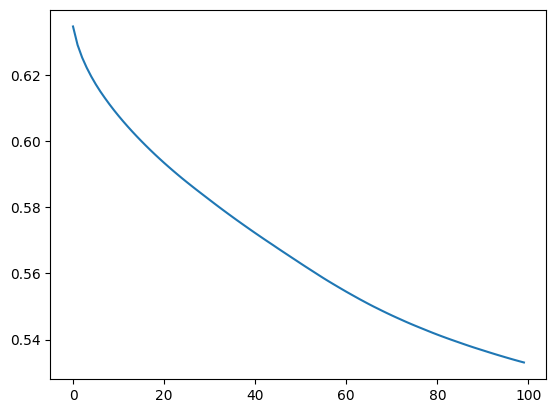

In [30]:
import matplotlib.pyplot as plt
plt.plot(model2_data.history['loss'])